## **Machine Learning Data Analysis: Tourist Behavior and Spending Trends**

#### Library Imports for Data Analysis and Visualization

The analysis utilizes several Python libraries: `NumPy` for numerical computations, `Pandas` for data manipulation and handling DataFrames, `Matplotlib` for creating static plots, and `Seaborn` for enhanced statistical visualizations. These libraries are essential for generating the boxplots of **overnight tourist trips** and **visitor spending**, as well as the barplot of **visitor spending** by year and area of residence, ensuring efficient data processing and clear visual representation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#### Loading the Processed Dataset

The dataset, stored as a CSV file named "Processed Data.csv" in a specified directory, is loaded into a Pandas DataFrame for analysis. This data, likely containing columns such as overnight tourist trips, visitor spending, year, and area of residence, serves as the foundation for generating the boxplots and barplot visualizations explored earlier.

In [4]:
data = pd.read_csv(r'H:\CCT\Git\msc-da-ca1-sem-1-Nandini162003\Dataset\Processed Data.csv')

- Multiplies all values in the `'Visitor Spending'` column by `1,000,000`  
- Assumes original values were in **millions** (e.g., `2.5` → `2,500,000`)  
- Common for financial/national park datasets where figures are scaled for readability  

In [6]:
data['Visitor Spending'] = data['Visitor Spending'] * 1000000


The `data.head()` function displays the first five rows of a DataFrame. It is useful for quickly inspecting the dataset's structure, column names, and data types. This helps in verifying data loading and identifying potential issues.


In [8]:
data.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips
0,2012,1,France,Business,6.6,9000000.0,9.0
1,2012,2,France,Business,5.8,6000000.0,6.0
2,2012,3,France,Business,9.3,6000000.0,7.0
3,2012,4,France,Business,9.1,5000000.0,5.0
4,2013,1,France,Business,6.0,7000000.0,8.0


### Log Transformation

Log transformation is a data transformation technique that applies the logarithm function to each data point, reducing skewness and handling wide-ranging values. It is commonly used to normalize distributions and stabilize variance in statistical analysis.  


#### Applying Log Transformation

The following transformation applies the natural logarithm (log1p) to the `"Visitor Stay Avg"` column and stores the result in a new column `"Visitor Stay Avg_Transformed"`.

In [11]:
data['Visitor Stay Avg_Transformed'] = np.log1p(data['Visitor Stay Avg'])

The following transformation applies the natural logarithm (`log1p`) to the `"Visitor Spending"` column and stores the result in a new column `"Visitor Spending_Transformed"`.

In [13]:
data['Visitor Spending_Transformed'] = np.log1p(data['Visitor Spending'])

The following transformation applies the natural logarithm (`log1p`) to the `"Overnight Tourist Trips"` column and stores the result in a new column `"Overnight Tourist Trips_Transformed"`.

In [15]:
data['Overnight Tourist Trips_Transformed'] = np.log1p(data['Overnight Tourist Trips'])

#### Displaying the First Few Rows of Data

The `data.head()` function returns the first five rows of a DataFrame by default. It helps in quickly inspecting the structure, column names, and sample values of the dataset.

In [17]:
data.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips,Visitor Stay Avg_Transformed,Visitor Spending_Transformed,Overnight Tourist Trips_Transformed
0,2012,1,France,Business,6.6,9000000.0,9.0,2.028148,16.012735,2.302585
1,2012,2,France,Business,5.8,6000000.0,6.0,1.916923,15.607270,1.945910
2,2012,3,France,Business,9.3,6000000.0,7.0,2.332144,15.607270,2.079442
3,2012,4,France,Business,9.1,5000000.0,5.0,2.312535,15.424949,1.791759
4,2013,1,France,Business,6.0,7000000.0,8.0,1.945910,15.761421,2.197225


#### Statistics of Data

The `data.describe()` function generates summary statistics for numerical columns in a DataFrame, providing insights into the distribution and central tendencies of the data.


In [19]:
data.describe()

,Year,Quarter,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips,Visitor Stay Avg_Transformed,Visitor Spending_Transformed,Overnight Tourist Trips_Transformed
count,896.000000,896.000000,896.000000,8.960000e+02,896.000000,896.000000,896.000000,896.000000
mean,2015.500000,2.500000,9.876563,3.755804e+07,14.290179,2.226621,16.824761,2.418589
std,2.292568,1.118658,7.132636,5.528475e+07,13.414599,0.546543,1.097662,0.766793
min,2012.000000,1.000000,0.500000,1.000000e+06,1.000000,0.405465,13.815512,0.693147
25%,2013.750000,1.750000,5.700000,8.000000e+06,5.000000,1.902108,15.894952,1.791759
50%,2015.500000,2.500000,7.800000,2.100000e+07,9.000000,2.174752,16.860033,2.302585
75%,2017.250000,3.250000,11.000000,4.500000e+07,19.000000,2.484907,17.622173,2.995732
max,2019.000000,4.000000,49.400000,5.540000e+08,68.000000,3.919991,20.132675,4.234107


#### Pairplot Visualization

The `sns.pairplot(data)` function generates pairwise scatter plots for numerical variables in the dataset, helping to explore relationships between features.


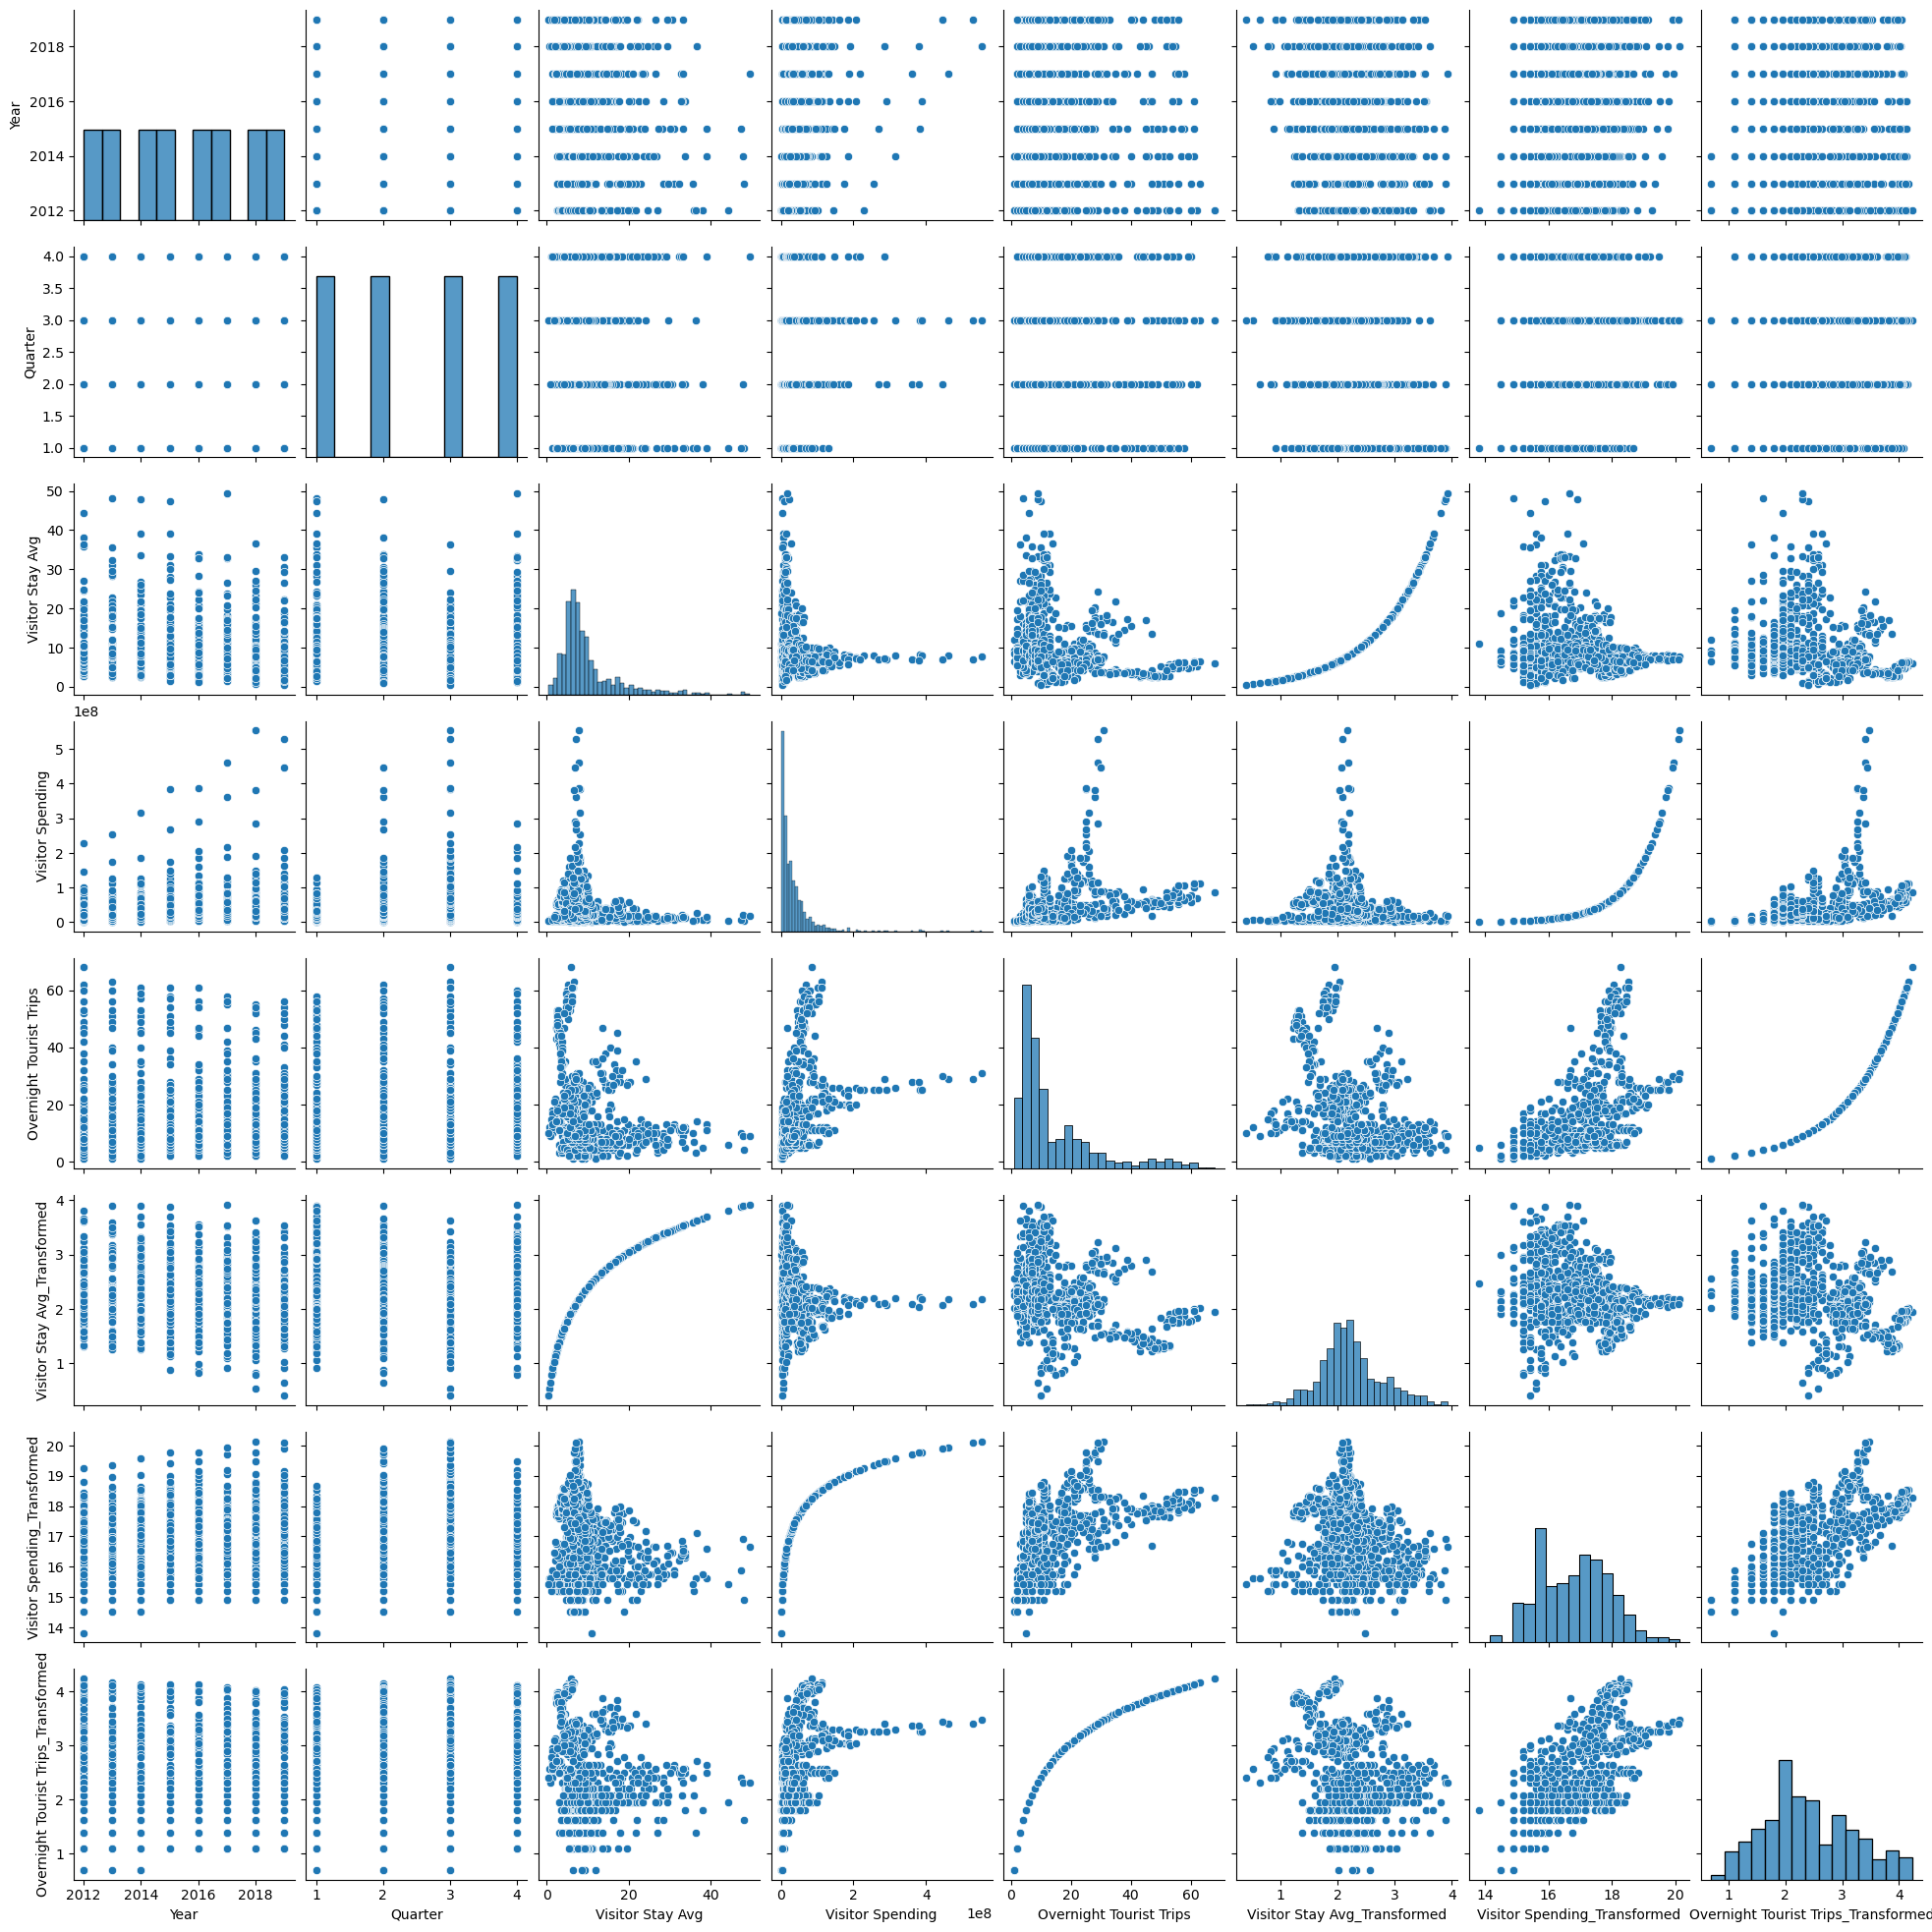

In [21]:
sns.pairplot(data)

This image is a **scatterplot matrix** (also known as a **pairs plot** or **correlation matrix plot**). It's a common way to visualize relationships between multiple numerical variables in a dataset. 

Here's a breakdown of how to interpret it:

#### **Structure:**

* **Grid:** The plot is arranged in a grid. Each cell represents the relationship between two variables.
* **Diagonal:** The diagonal cells (from top-left to bottom-right) show the distribution of a single variable using a **histogram** or a **density                        plot**.
* **Off-Diagonal:** The off-diagonal cells show the relationship between two variables using a **scatterplot**.

#### **Variables:**

The variables shown in the plot are:

* **Year:** The year of the data points.
* **Quarter:** The quarter of the year.
* **Visitor Stay Avg:** The average length of visitor stay.
* **Visitor Spending:** The amount visitors spend.
* **Overnight Tourist Trips:** The number of overnight tourist trips.
* **Visitor Stay Avg_Transformed:** A transformed version of "Visitor Stay Avg". (Likely a logarithmic or other non-linear transformation).
* **Visitor Spending_Transformed:** A transformed version of "Visitor Spending".
* **Overnight Tourist Trips_Transformed:** A transformed version of "Overnight Tourist Trips".

#### **Interpreting the Plots:**

* **Histograms (Diagonal):** These show the distribution of each individual variable. You can observe if the data is normally distributed, skewed, or has outliers.
* **Scatterplots (Off-Diagonal):** These show the relationship between two variables.
    * **Trends:** Look for trends like positive correlation (as one variable increases, the other also tends to increase), negative correlation (as one variable increases, the other tends to decrease), or no correlation (random scatter).
    * **Strength:** The closer the points are to a straight line, the stronger the correlation.
    * **Patterns:** Look for patterns like clusters, non-linear relationships, or outliers.


#### Categories:

* Area of Residence
* Reason for Journey

In [24]:
categories = ['Area of Residence', 'Reason for Journey']

In [25]:
from sklearn.preprocessing import OneHotEncoder

#### Explanation:
- **`sklearn.preprocessing`**: The scikit-learn module containing data preprocessing utilities.
- **`OneHotEncoder`**: A transformer that converts categorical features into a one-hot encoded numeric array (binary columns for each category).

In [27]:
ohe = OneHotEncoder(sparse_output=False, drop = 'first')

- `sparse_output=False`: Returns a dense array (not sparse matrix).
- `drop='first'`: Drops the first category to avoid multicollinearity (useful for linear models).

In [29]:
data_encoded = ohe.fit_transform(data[['Area of Residence', 'Reason for Journey']])

**Parameters:**
- `ohe`: Pre-initialized OneHotEncoder instance (`sparse_output=False`, `drop='first'`)
- `data[['Area of Residence', 'Reason for Journey']]`: DataFrame subset containing categorical columns to encode

**Returns:**
- `data_encoded`: Dense NumPy array of one-hot encoded features (first category dropped for each feature)

In [31]:
dataframe_encoded = pd.DataFrame(data_encoded, columns=ohe.get_feature_names_out())

Creates a Pandas DataFrame `dataframe_encoded` from one-hot encoded data (`data_encoded`), using column names generated by the `OneHotEncoder` (`ohe`).

#### Displaying the First Few Rows of a DataFrame
- **Purpose**: Displays the first five rows of the `dataframe_encoded`.
- **Usage**: Helps in quickly inspecting the top rows of the dataset after encoding categorical variables.
- **Syntax**:  
  ```python
  dataframe_encoded.head()


In [34]:
dataframe_encoded.head()

,Area of Residence_Germany,Area of Residence_Great Britain,Area of Residence_Italy,Area of Residence_Other Europe (14),Area of Residence_Other countries (24),Area of Residence_United States and Canada,Reason for Journey_Holiday/leisure/recreation,Reason for Journey_Other reason for journey,Reason for Journey_Visit to friends/relatives
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### **Merging Encoded Data with Original DataFrame**  
- **Explanation**:  
  - `pd.concat()` is used to concatenate two DataFrames.  
  - `axis=1` ensures the merge happens **column-wise**, adding the encoded features to the original dataset.  
  - This results in a new DataFrame, `merged_data`, containing both original and encoded features.

In [36]:
merged_data = pd.concat([data, dataframe_encoded], axis=1)

#### **Displaying the First Few Rows of Merged Data**  
- **Explanation**:  
  - This function helps in verifying that the original and encoded data have been successfully merged.  
  - It allows quick inspection of the dataset's structure, ensuring all necessary columns are present.

In [38]:
merged_data.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips,Visitor Stay Avg_Transformed,Visitor Spending_Transformed,Overnight Tourist Trips_Transformed,Area of Residence_Germany,Area of Residence_Great Britain,Area of Residence_Italy,Area of Residence_Other Europe (14),Area of Residence_Other countries (24),Area of Residence_United States and Canada,Reason for Journey_Holiday/leisure/recreation,Reason for Journey_Other reason for journey,Reason for Journey_Visit to friends/relatives
0,2012,1,France,Business,6.6,9000000.0,9.0,2.028148,16.012735,2.302585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012,2,France,Business,5.8,6000000.0,6.0,1.916923,15.607270,1.945910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012,3,France,Business,9.3,6000000.0,7.0,2.332144,15.607270,2.079442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012,4,France,Business,9.1,5000000.0,5.0,2.312535,15.424949,1.791759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013,1,France,Business,6.0,7000000.0,8.0,1.945910,15.761421,2.197225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### **Standard Scaling in Machine Learning**  

**Standard Scaling** (also called **Standardization**) is a feature scaling technique that transforms data to have a **mean of 0** and a **standard deviation of 1**. This makes the data **normally distributed** and helps machine learning models perform better.  

#### **Formula for Standard Scaling:**  
\[
X_{\text{scaled}} = \frac{X - \mu}{\sigma}
\]
Where:  
- \( X \) = Original feature value  
- \( \mu \) = Mean of the feature  
- \( \sigma \) = Standard deviation of the feature  

#### **Importing StandardScaler for Feature Scaling**  
- **Explanation**:  
  - This import allows you to apply **Standard Scaling** to your dataset.  
  - It helps improve the performance of machine learning models that rely on numerical feature distributions.

In [41]:
from sklearn.preprocessing import StandardScaler

#### **Initializing the StandardScaler**  
  - This initializes the `StandardScaler` object, which can be used to **fit** and **transform** data.  
  - It ensures that features have a **mean of 0** and a **standard deviation of 1**, improving model performance.

In [43]:
scaler = StandardScaler()

#### Scaling Visitor Stay Data,Overnight Tourist Trips,Visitor Spending.

`-`The column **Visitor Stay Avg_Transformed** is scaled using **scaler.fit_transform()**, and the result is stored in `'Visitor Stay Avg Scaled'`.

`-`The column **Overnight Tourist Trips_Transformed** is scaled using **scaler.fit_transform()**, and the result is stored in `'Overnight Tourist Trips Scaled'`.

`-`The column **Visitor Spending_Transformed** is scaled using **scaler.fit_transform()**, and the result is stored in `'Visitor Spending Scaled'`.  




In [45]:
merged_data['Visitor Stay Avg Scaled'] = scaler.fit_transform(merged_data[['Visitor Stay Avg_Transformed']])

In [46]:
merged_data['Overnight Tourist Trips Scaled'] = scaler.fit_transform(merged_data[['Overnight Tourist Trips_Transformed']])

In [47]:
merged_data['Visitor Spending Scaled'] = scaler.fit_transform(merged_data[['Visitor Spending_Transformed']])

#### Displaying Data Overview  
The `head()` function returns the first five rows of `merged_data`, providing a quick preview of the dataset.

In [49]:
merged_data.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips,Visitor Stay Avg_Transformed,Visitor Spending_Transformed,Overnight Tourist Trips_Transformed,...,Area of Residence_Italy,Area of Residence_Other Europe (14),Area of Residence_Other countries (24),Area of Residence_United States and Canada,Reason for Journey_Holiday/leisure/recreation,Reason for Journey_Other reason for journey,Reason for Journey_Visit to friends/relatives,Visitor Stay Avg Scaled,Overnight Tourist Trips Scaled,Visitor Spending Scaled
0,2012,1,France,Business,6.6,9000000.0,9.0,2.028148,16.012735,2.302585,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.363345,-0.151369,-0.740190
1,2012,2,France,Business,5.8,6000000.0,6.0,1.916923,15.607270,1.945910,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.566966,-0.616780,-1.109786
2,2012,3,France,Business,9.3,6000000.0,7.0,2.332144,15.607270,2.079442,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.193181,-0.442541,-1.109786
3,2012,4,France,Business,9.1,5000000.0,5.0,2.312535,15.424949,1.791759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.157284,-0.817926,-1.275979
4,2013,1,France,Business,6.0,7000000.0,8.0,1.945910,15.761421,2.197225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.513899,-0.288850,-0.969272



#### Defining Features and Target Variables  
`X` stores feature values from columns 9 to the second last, while `y` stores the target variable from the last column of `merged_data`. 

In [51]:
X = merged_data.iloc[:, 9:-1].values
y = merged_data.iloc[:, -1].values

#### **Importing Essential Libraries for Linear Regression**  

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

  - `LinearRegression`: Imports the Linear Regression model from `sklearn.linear_model`.  
  - `train_test_split`: Splits the dataset into training and testing sets for model validation.  
  - `GridSearchCV`: Performs hyperparameter tuning to find the best model parameters.  
  - `mean_squared_error (MSE)`: Measures the average squared difference between actual and predicted values (lower is better).  
  - `r2_score (R²)`: Evaluates the proportion of variance explained by the model (higher is better).

#### **Splitting Data into Training and Testing Sets**   

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

  - train_test_split(X, y, test_size=0.2, random_state=0):  
    - **X**: Features (independent variables).  
    - **y**: Target variable (dependent variable).  
    - **test_size=0.2**: Allocates **20%** of the data for testing and **80%** for training.  
    - **random_state=0**: Ensures reproducibility by fixing the random split.  
  - X_train, X_test: Training and testing subsets for features.  
  - y_train, y_test: Training and testing subsets for the target variable.  

#### **Training and Evaluating a Linear Regression Model**  

In [59]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_y_pred = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, lin_y_pred)
r2_lin = r2_score(y_test, lin_y_pred)

- **Explanation**:  
  - `LinearRegression()`: Creates an instance of the Linear Regression model.  
  - `fit(X_train, y_train)`: Trains the model on the training dataset.  
  - `predict(X_test)`: Makes predictions on the test dataset.  
  - `mean_squared_error(y_test, lin_y_pred)`: Calculates the **Mean Squared Error (MSE)** to measure prediction accuracy (lower is better).  
  - `r2_score(y_test, lin_y_pred)`: Computes the **R² score**, which indicates how well the model explains variance in the data (closer to 1 is better) 

#### **Defining Hyperparameter Grid for Random Forest Tuning**  

- **Purpose**: Creates a dictionary of hyperparameters for **Random Forest Regression** to be optimized using **GridSearchCV**.  

  

In [62]:
hyper_parameter_tuning_RF = {
    'n_estimators': [50, 100, 200],
    'min_samples_split': [1,2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_depth': [10, 20,30]
}


- **Explanation of Parameters**:  
  - **`n_estimators`**: Number of trees in the forest (**50, 100, 200**).  
  - **`min_samples_split`**: Minimum number of samples required to split an internal node (**1, 2, 5, 10**).  
  - **`min_samples_leaf`**: Minimum number of samples required in a leaf node (**1, 2, 4**).  
  - **`max_depth`**: Maximum depth of each tree (**10, 20, 30**), preventing overfitting.

#### **Defining Hyperparameter Grid for Support Vector Regression (SVR) Tuning**  

- **Purpose**: Creates a dictionary of hyperparameters for **Support Vector Regression (SVR)** to be optimized using **GridSearchCV**.  
 

In [64]:
hyper_parameter_tuning_SVR = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.3],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 1]
}


- **Explanation of Parameters**:  
  - **`C`**: Regularization parameter that controls the trade-off between achieving a low error and avoiding overfitting (**0.1, 1, 10, 100**).  
  - **`epsilon`**: Defines a margin of tolerance where predictions are not penalized for being within this range (**0.01, 0.1, 0.2, 0.3**).  
  - **`kernel`**: Specifies the kernel type for SVR (**'rbf' (Radial Basis Function), 'linear'**).  
  - **`gamma`**: Defines how much influence a single data point has (**'scale', 'auto', 0.1, 1**). 

#### **Defining Hyperparameter Grid for Lasso Regression Tuning**  

- **Purpose**: Creates a dictionary of hyperparameters for **Lasso Regression** to be optimized using **GridSearchCV**.  
  

In [65]:
hyper_parameter_tuning_lasso = {
    'alpha' : np.logspace(-4, 4, 20)
}


- **Explanation of Parameters**:  
  - **`alpha`**: The regularization strength parameter, controlling the **penalty on model complexity**.  
    - `np.logspace(-4, 4, 20)`: Generates **20 values logarithmically spaced** between \(10^{-4}\) and \(10^4\).  
    - **Lower alpha values**: Less regularization, leading to a more complex model.  
    - **Higher alpha values**: More regularization, reducing overfitting but potentially underfitting.

#### **Lasso Regression: Hyperparameter Tuning and Model Evaluation**  

- **Purpose**:  
  - Uses **GridSearchCV** to find the best **alpha** value for **Lasso Regression**.  
  - Trains the optimized model, makes predictions, and evaluates performance using **MSE** and **R² score**.  
  

#### What is `alpha` in Lasso Regression?  

`alpha` is the **regularization strength parameter** in **Lasso Regression**. It controls the **amount of shrinkage** applied to the regression coefficients, which helps prevent overfitting by reducing some coefficients to zero.  

#### Conclusion  
- **Smaller `alpha`** → More complex model, less regularization.  
- **Larger `alpha`** → Simpler model, more regularization, and automatic **feature selection**.  
- The optimal `alpha` balances **bias and variance**, leading to better generalization. 

In [66]:
from sklearn.linear_model import Lasso

grd_srch_lasso = GridSearchCV(Lasso(), hyper_parameter_tuning_lasso, cv=5, scoring='neg_mean_squared_error')
grd_srch_lasso.fit(X_train, y_train)
optimized_lasso = grd_srch_lasso.best_estimator_
y_prediction_lasso = optimized_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_prediction_lasso)
r2_score_lasso = r2_score(y_test, y_prediction_lasso)


- **Explanation**:  
  - GridSearchCV(Lasso(), hyper_parameter_tuning_lasso, cv=5, scoring='neg_mean_squared_error')  
    - Performs **5-fold cross-validation** to find the best **alpha** for Lasso Regression.  
    - Uses **Negative Mean Squared Error (MSE)** as the scoring metric.  
  - grd_srch_lasso.fit(X_train, y_train): Fits the Lasso model on training data.  
  - grd_srch_lasso.best_estimator_: Retrieves the best Lasso model.  
  - optimized_lasso.predict(X_test): Makes predictions on the test data.  
  - mean_squared_error(y_test, y_prediction_lasso): Computes **MSE** (lower is better).  
  - r2_score(y_test, y_prediction_lasso): Computes **R² score** (closer to 1 is better).

#### **Importing Models and Evaluation Metrics**  

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


  - `RandomForestRegressor`: Implements a **Random Forest** model for regression tasks, using multiple decision trees to improve predictions.  
  - `SVR`: Implements **Support Vector Regression (SVR)**, a model that uses Support Vector Machines (SVM) for regression problems.  


#### **Grid Search for Random Forest Regression**  

- **Purpose**: Uses **GridSearchCV** to find the best hyperparameters for **Random Forest Regressor**, optimizing model performance.  


In [71]:
grd_srch_RF = GridSearchCV(RandomForestRegressor(), param_grid=hyper_parameter_tuning_RF, cv=5, scoring='neg_mean_squared_error', verbose=2)

- **Explanation of Parameters**:  
  - `RandomForestRegressor()`: Initializes a **Random Forest Regression model**.  
  - `param_grid=hyper_parameter_tuning_RF`: Provides the predefined **hyperparameter grid** for tuning.  
  - `cv=5`: Performs **5-fold cross-validation** to evaluate different hyperparameter combinations.  
  - `scoring='neg_mean_squared_error'`: Uses **Negative Mean Squared Error (MSE)** as the metric (lower is better).  
  - `verbose=2`: Displays **detailed progress** of the grid search.  


#### **Training and Evaluating the Optimized Random Forest Model**  

- **Purpose**:  
  - Fits the **GridSearchCV-optimized Random Forest model** to the training data.  
  - Makes predictions on the test set.  
  - Computes performance metrics (**MSE and R² score**) for evaluation.  

In [74]:
grd_srch_RF.fit(X_train, y_train)
optimized_RF = grd_srch_RF.best_estimator_
y_prediction_RF = optimized_RF.predict(X_test)
mse_RF = mean_squared_error(y_test, y_prediction_RF)
r2_RF = r2_score(y_test, y_prediction_RF)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=50; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, min_sample

- **Explanation**:  
  - `grd_srch_RF.fit(X_train, y_train)`:  
    - Trains **Random Forest** using the best hyperparameters found by **GridSearchCV**.  
  - `grd_srch_RF.best_estimator_`:  
    - Retrieves the **best model** from Grid Search.  
  - `optimized_RF.predict(X_test)`:  
    - Uses the trained model to **predict** on test data.  
  - `mean_squared_error(y_test, y_prediction_RF)`:  
    - Calculates **MSE (Mean Squared Error)** (lower is better).  
  - `r2_score(y_test, y_prediction_RF)`:  
    - Calculates **R² score** (closer to 1 is better).  

#### **Training and Evaluating the Optimized Support Vector Regression (SVR) Model**  

- **Purpose**:  
  - Fits the **GridSearchCV-optimized Support Vector Regression (SVR)** model to the training data.  
  - Makes predictions on the test set.  
  - Computes performance metrics (**MSE and R² score**) to evaluate model performance.  


In [139]:
grd_srch_svr = GridSearchCV(SVR(), hyper_parameter_tuning_SVR, scoring='neg_mean_squared_error', verbose=1)

grd_srch_svr.fit(X_train, y_train)
optimized_svr = grd_srch_svr.best_estimator_
y_prediction_svr = optimized_svr.predict(X_test)
mse_svr = mean_squared_error(y_test, y_prediction_svr)
r2_svr = r2_score(y_test, y_prediction_svr)

Fitting 5 folds for each of 128 candidates, totalling 640 fits



- **Explanation**:  
  - `GridSearchCV(SVR(), hyper_parameter_tuning_SVR, scoring='neg_mean_squared_error', verbose=1)`:  
    - Performs **Grid Search** to find the best hyperparameters for the **Support Vector Regression** model.  
    - Uses **Negative Mean Squared Error (MSE)** as the scoring metric.  
  - `grd_srch_svr.fit(X_train, y_train)`:  
    - Trains the **SVR model** using the best hyperparameters discovered by **GridSearchCV**.  
  - `grd_srch_svr.best_estimator_`:  
    - Retrieves the **best SVR model** with the optimal parameters.  
  - `optimized_svr.predict(X_test)`:  
    - Predicts values using the optimized model on the test set.  
  - `mean_squared_error(y_test, y_prediction_svr)`:  
    - Computes **MSE (Mean Squared Error)** to assess prediction accuracy (lower is better).  
  - `r2_score(y_test, y_prediction_svr)`:  
    - Computes **R² score** to measure the model's goodness of fit (closer to 1 is better).

#### **Displaying Model Performance Metrics**

- **Purpose**:  
  - Prints the **Mean Squared Error (MSE)** and **R² score** for multiple regression models:  
    - **Linear Regression**  
    - **Random Forest Regression**  
    - **Support Vector Regression**  
    - **Lasso Regression**



In [77]:
print(f'MSE for Linear Regression: {mse_lin}')
print(f'R2 for Linear Regression: {r2_lin} \n')
print(f'MSE for Random Forest Regression: {mse_RF}')
print(f'R2 for Random Forest Regression: {r2_RF} \n')
print(f'MSE for Support Vector Regression: {mse_svr}')
print(f'R2 for Support Vector Regression: {r2_svr} \n')
print(f'MSE for Linear Regression (Lasso): {mse_lasso}')
print(f'R2 for Linear Regression (Lasso): {r2_score_lasso}')

MSE for Linear Regression: 0.11596182103668506
R2 for Linear Regression: 0.8945467258237222 

MSE for Random Forest Regression: 0.08897028406806172
R2 for Random Forest Regression: 0.9190922695461765 

MSE for Support Vector Regression: 0.09119022447867976
R2 for Support Vector Regression: 0.9170735017941434 

MSE for Linear Regression (Lasso): 0.1157784795559427
R2 for Linear Regression (Lasso): 0.8947134527625006


- **Explanation**:  
  - mse_lin, r2_lin: **Mean Squared Error** and **R² score** for the **Linear Regression** model.  
  - mse_RF, r2_RF: **Mean Squared Error** and **R² score** for the **Random Forest Regression** model.  
  - mse_svr, r2_svr: **Mean Squared Error** and **R² score** for the **Support Vector Regression** model.  
  - mse_lasso, r2_score_lasso: **Mean Squared Error** and **R² score** for the **Lasso Regression** model.  

#### **Visualizing Predictions for Different Regression Models**  

- **Purpose**:  
  - Creates a **2×2 grid of scatter plots** to compare the predicted vs. actual values for different regression models:  
    1. **Random Forest Regression**  
    2. **Linear Regression**  
    3. **Lasso Regression**  
    4. **Support Vector Regression (SVR)**  

- **Explanation**:  
  - `plt.subplots(2,2, figsize=(10,8))`: Creates a **2×2 subplot** layout.  
  - **Scatter Plots**:  
    - Each subplot shows **actual vs. predicted values** for a model.  
    - A **dashed red line** represents the **ideal prediction** (where predicted values match actual values).  
  - **Legend**: Indicates the predicted values and reference line.  
  - `plt.tight_layout()`: Adjusts spacing for better readability.  

- **Interpretation**:  
  - The **closer** the scatter points are to the **red dashed line**, the **better the model's predictions**.  
  - A **wider spread** means the model **struggles with accuracy**.  

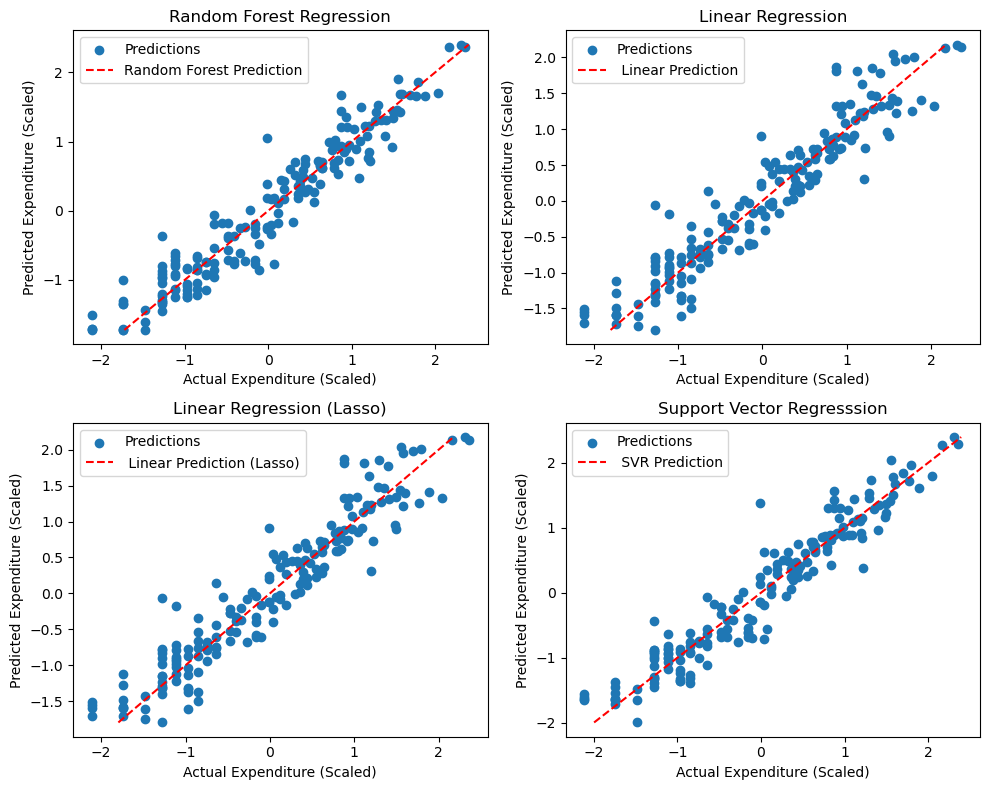

In [79]:
fig, axis = plt.subplots(2,2, figsize=(10,8))

# Scatter plot for Random Forest
axis[0,0].scatter(y_test, y_prediction_RF, label="Predictions")
axis[0,0].plot(
    [y_prediction_RF.min(), y_prediction_RF.max()], 
    [y_prediction_RF.min(), y_prediction_RF.max()], 
    color='red', linestyle='--', label="Random Forest Prediction"
)
axis[0,0].set_xlabel("Actual Expenditure (Scaled)")
axis[0,0].set_ylabel("Predicted Expenditure (Scaled)")
axis[0,0].set_title("Random Forest Regression")
axis[0,0].legend()

# Scatter plot for Linear Regression
axis[0,1].scatter(y_test, lin_y_pred, label="Predictions")
axis[0,1].plot(
    [lin_y_pred.min(), lin_y_pred.max()], 
    [lin_y_pred.min(), lin_y_pred.max()], 
    color='red', linestyle='--', label=" Linear Prediction"
)
axis[0,1].set_xlabel("Actual Expenditure (Scaled)")
axis[0,1].set_ylabel("Predicted Expenditure (Scaled)")
axis[0,1].set_title("Linear Regression")
axis[0,1].legend()

# Scatter plot for Linear Regression Lasso
axis[1,0].scatter(y_test, y_prediction_lasso, label="Predictions")
axis[1,0].plot(
    [y_prediction_lasso.min(), y_prediction_lasso.max()], 
    [y_prediction_lasso.min(), y_prediction_lasso.max()], 
    color='red', linestyle='--', label=" Linear Prediction (Lasso)"
)
axis[1,0].set_xlabel("Actual Expenditure (Scaled)")
axis[1,0].set_ylabel("Predicted Expenditure (Scaled)")
axis[1,0].set_title("Linear Regression (Lasso)")
axis[1,0].legend()

# Scatter plot for SVR
axis[1,1].scatter(y_test, y_prediction_svr, label="Predictions")
axis[1,1].plot(
    [y_prediction_svr.min(), y_prediction_svr.max()], 
    [y_prediction_svr.min(), y_prediction_svr.max()], 
    color='red', linestyle='--', label=" SVR Prediction"
)
axis[1,1].set_xlabel("Actual Expenditure (Scaled)")
axis[1,1].set_ylabel("Predicted Expenditure (Scaled)")
axis[1,1].set_title("Support Vector Regresssion")
axis[1,1].legend()

plt.tight_layout()
plt.show()

This image contains four scatter plots comparing actual vs. predicted values of scaled expenditure using different regression models. The goal is to evaluate how well each model predicts expenditure.

#### **Breakdown of Each Plot:**

1. **Top Left: Random Forest Regression**
   - **Blue dots**: Actual vs. predicted expenditure points.
   - **Red dashed line**: The ideal prediction line (Random Forest model).
   - **Observation**: The points are closely clustered around the red line, indicating strong predictive accuracy. Random Forest, being an ensemble model, captures complex patterns effectively.

2. **Top Right: Linear Regression**
   - **Blue dots**: Actual vs. predicted values.
   - **Red dashed line**: Linear regression’s predictions.
   - **Observation**: While there is a visible trend, some points deviate from the line, especially at extreme values. Linear regression struggles when relationships are nonlinear.

3. **Bottom Left: Lasso Regression (Linear Regression with Regularization)**
   - **Blue dots**: Actual vs. predicted values.
   - **Red dashed line**: Lasso regression’s predictions.
   - **Observation**: The behavior is similar to standard linear regression but with slightly better generalization due to regularization, reducing overfitting.

4. **Bottom Right: Support Vector Regression (SVR)**
   - **Blue dots**: Actual vs. predicted values.
   - **Red dashed line**: SVR’s predictions.
   - **Observation**: The predictions align well with the red line, indicating strong performance. SVR is effective at capturing complex relationships, though it may be sensitive to parameter tuning.

#### **Key Takeaways:**
- **Best Performance**: Random Forest Regression and Support Vector Regression, as their predictions align well with actual values.
- **Decent Performance**: Lasso and Linear Regression show good but slightly weaker alignment.
- **Conclusion**: Random Forest and SVR are preferable for predicting expenditure due to their ability to handle complex relationships.
